In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

%matplotlib inline

In [112]:
df = pd.read_csv('Final Integrated Tiktok Data.csv')

In [113]:
print("Columns and types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:\n", df.describe())


Columns and types:
 username               object
created_at             object
likes                   int64
comments                int64
shares                  int64
views                   int64
engagement_rate       float64
post_date              object
posts_per_day           int64
views_per_video       float64
likes_per_video       float64
comments_per_video    float64
dtype: object

Missing values:
 username              0
created_at            0
likes                 0
comments              0
shares                0
views                 0
engagement_rate       0
post_date             0
posts_per_day         0
views_per_video       0
likes_per_video       0
comments_per_video    0
dtype: int64

Basic statistics:
               likes      comments        shares         views  \
count  2.627000e+03  2.627000e+03  2.627000e+03  2.627000e+03   
mean   5.554968e+06  3.968155e+04  4.460856e+05  4.733789e+07   
std    7.931654e+06  9.565390e+04  1.376101e+06  7.481003e+07   
min    

In [114]:

# Ensure datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df = df.dropna(subset=['created_at'])

# Extract time features
df['post_date'] = df['created_at'].dt.date
df['hour'] = df['created_at'].dt.hour
df['weekday'] = df['created_at'].dt.day_name()

In [115]:
df

,username,created_at,likes,comments,shares,views,engagement_rate,post_date,posts_per_day,views_per_video,likes_per_video,comments_per_video,hour,weekday
0,661._miaa,2024-09-16 17:56:17+00:00,183900,329,3361,826700,0.226914,2024-09-16,1,826700.0,183900.0,329.0,17,Monday
1,chasityromann,2024-06-03 22:22:38+00:00,236600,379,5518,2600000,0.093268,2024-06-03,1,2600000.0,236600.0,379.0,22,Monday
2,lindceybeautyy,2024-08-04 14:26:09+00:00,404000,936,9560,3200000,0.129530,2024-08-04,1,3200000.0,404000.0,936.0,14,Sunday
3,iannelsonnnnn,2024-05-28 21:38:48+00:00,359300,936,11700,3500000,0.106267,2024-05-28,1,3500000.0,359300.0,936.0,21,Tuesday
4,nightmoonxyz,2025-04-23 04:25:50+00:00,2391,99,118,48600,0.053663,2025-04-23,1,48600.0,2391.0,99.0,4,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,geograpyh.geniuse,2025-02-08 10:27:18+00:00,83100,321,1459,3400000,0.024965,2025-02-08,1,3400000.0,83100.0,321.0,10,Saturday
1206,evimawete,2025-12-24 17:04:50+00:00,292,12,7,2846,0.109276,2025-12-24,1,2846.0,292.0,12.0,17,Wednesday
1207,brookemonk_,2024-02-24 21:32:23+00:00,6900000,8822,7165,74900000,0.092336,2024-02-24,1,74900000.0,6900000.0,8822.0,21,Saturday
1208,bruhwutisthis_0,2024-11-24 23:11:49+00:00,307700,1500,14000,1300000,0.248615,2024-11-24,1,1300000.0,307700.0,1500.0,23,Sunday


In [116]:
import pandas as pd

# Columns to check for outliers
numeric_cols = ['likes', 'comments', 'shares', 'views', 'engagement_rate', 'posts_per_day']

# Remove outliers using one-pass IQR method and overwrite df
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Keep only rows inside the IQR range
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Check how many rows remain
print(f"Rows after removing outliers: {len(df)}")




Rows after removing outliers: 682


In [117]:
numeric_cols = ['likes', 'comments', 'shares', 'views', 'engagement_rate', 'posts_per_day']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers remaining")


likes: 79 outliers remaining
comments: 61 outliers remaining
shares: 86 outliers remaining
views: 29 outliers remaining
engagement_rate: 0 outliers remaining
posts_per_day: 0 outliers remaining


c:\Users\Ahmed\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


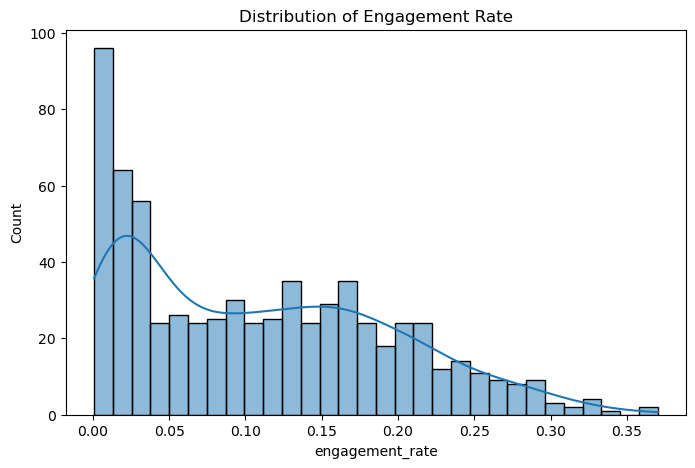

In [118]:
plt.figure(figsize=(8,5))
sns.histplot(df['engagement_rate'], bins=30, kde=True)
plt.title('Distribution of Engagement Rate')
plt.show()


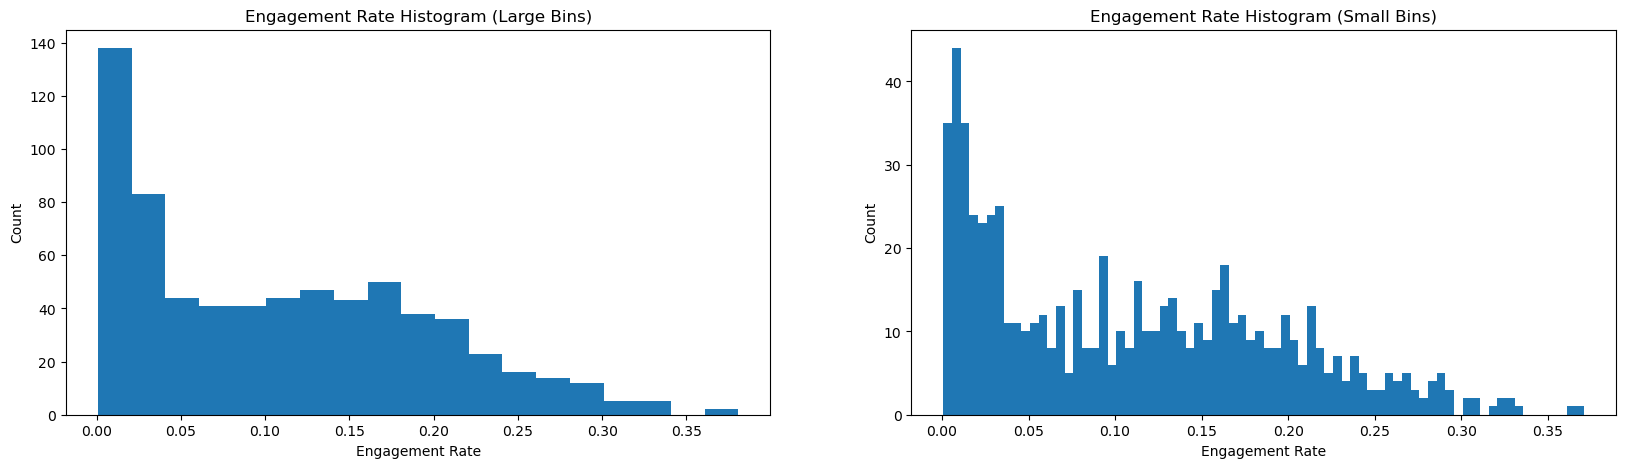

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure no missing values
data = df['engagement_rate'].dropna()

# Resize figure
plt.figure(figsize=(20, 5))

# -----------------------------
# Left: Large bin size
# -----------------------------
plt.subplot(1, 2, 1)
bins_large = np.arange(
    data.min(),
    data.max() + 0.02,
    0.02
)
plt.hist(data, bins=bins_large)
plt.title('Engagement Rate Histogram (Large Bins)')
plt.xlabel('Engagement Rate')
plt.ylabel('Count')

# -----------------------------
# Right: Small bin size
# -----------------------------
plt.subplot(1, 2, 2)
bins_small = np.arange(
    data.min(),
    data.max() + 0.005,
    0.005
)
plt.hist(data, bins=bins_small)
plt.title('Engagement Rate Histogram (Small Bins)')
plt.xlabel('Engagement Rate')
plt.ylabel('Count')

plt.show()


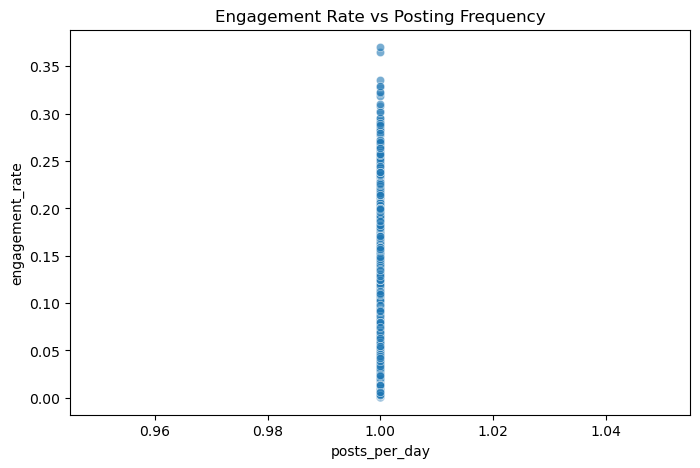

In [120]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='posts_per_day', y='engagement_rate', data=df, alpha=0.6)
plt.title('Engagement Rate vs Posting Frequency')
plt.show()


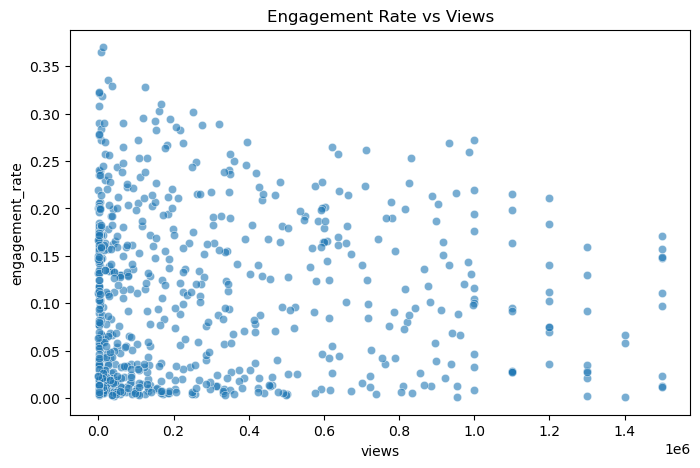

In [121]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='views', y='engagement_rate', data=df, alpha=0.6)
plt.title('Engagement Rate vs Views')
plt.show()


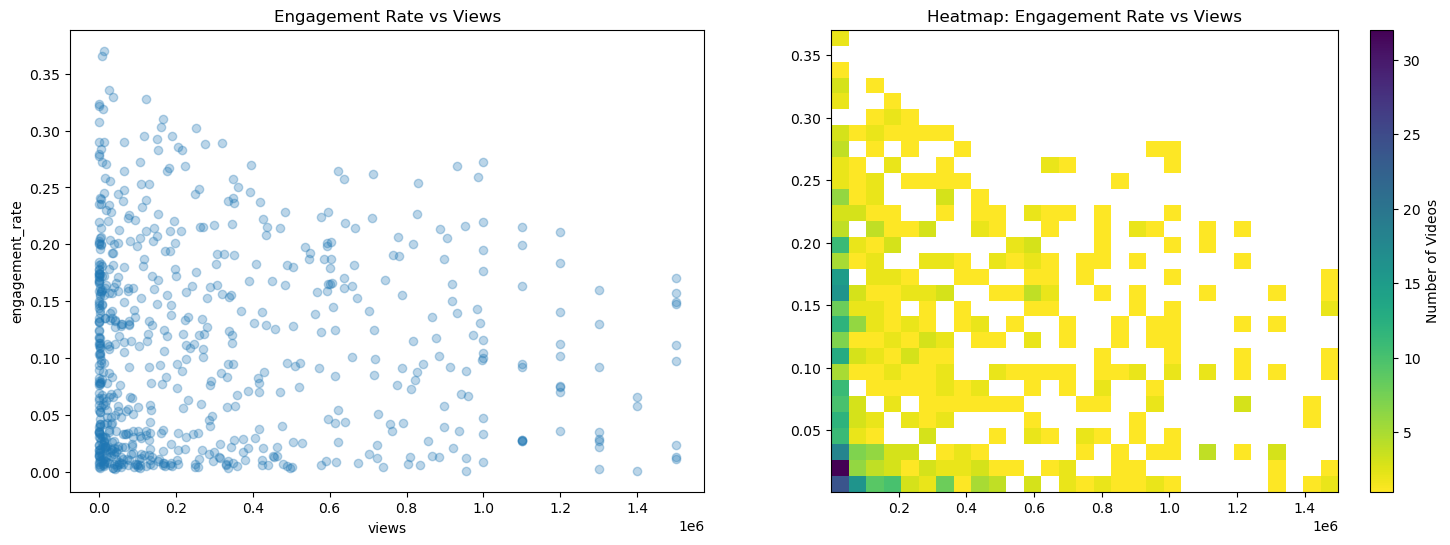

In [122]:
plt.figure(figsize=(18,6))

# Scatter
plt.subplot(1,2,1)
sns.regplot(
    data=df,
    x='views',
    y='engagement_rate',
    scatter_kws={'alpha':0.3},
    fit_reg=False
)
plt.title('Engagement Rate vs Views')

# Heatmap
plt.subplot(1,2,2)

bins_x = np.linspace(
    df['views'].min(),
    df['views'].max(),
    30
)

bins_y = np.linspace(
    df['engagement_rate'].min(),
    df['engagement_rate'].max(),
    30
)

plt.hist2d(
    df['views'],
    df['engagement_rate'],
    bins=[bins_x, bins_y],
    cmin=1,
    cmap='viridis_r'
)

plt.colorbar(label='Number of Videos')
plt.title('Heatmap: Engagement Rate vs Views')
plt.show()



In [123]:
print(df['posts_per_day'].value_counts())
print(df['posts_per_day'].min(), df['posts_per_day'].max())


posts_per_day
1    682
Name: count, dtype: int64
1 1


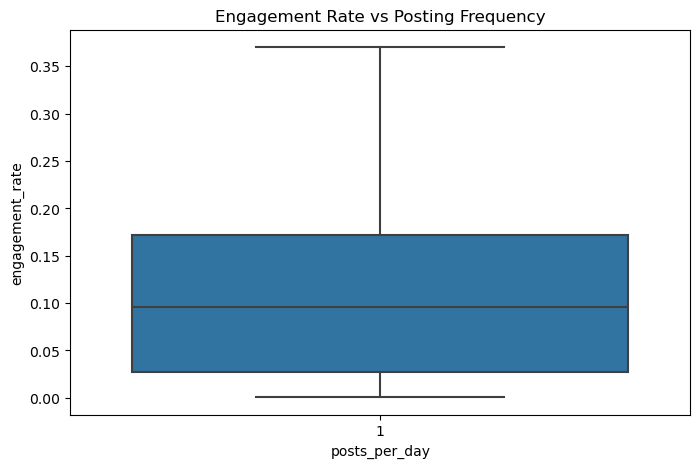

In [124]:
plt.figure(figsize=(8,5))
sns.boxplot(x='posts_per_day', y='engagement_rate', data=df)
plt.title('Engagement Rate vs Posting Frequency')
plt.show()




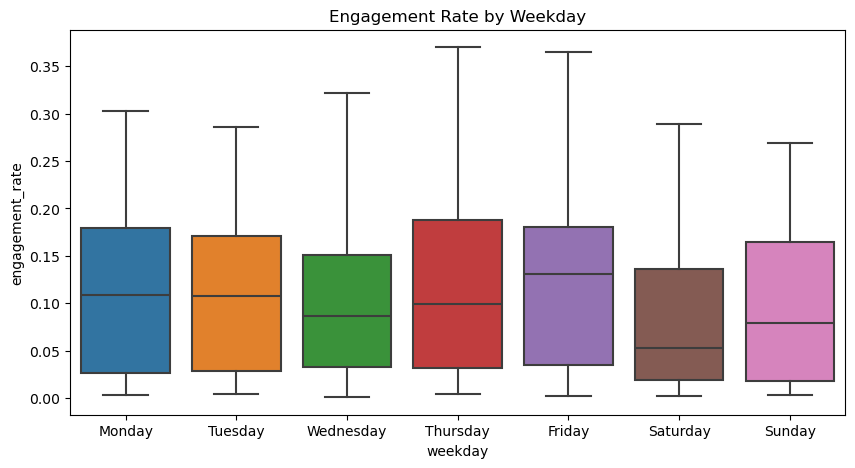

In [125]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='weekday',
    y='engagement_rate',
    data=df,
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title('Engagement Rate by Weekday')
plt.show()


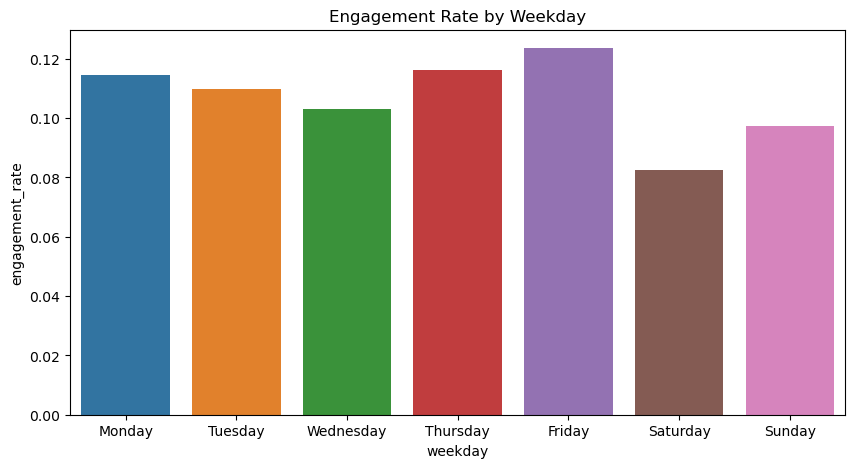

In [126]:
df_day = df.groupby('weekday', as_index=False)['engagement_rate'].mean()

plt.figure(figsize=(10,5))
sns.barplot(
    x='weekday',
    y='engagement_rate',
    data=df_day,
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title('Engagement Rate by Weekday')
plt.show()


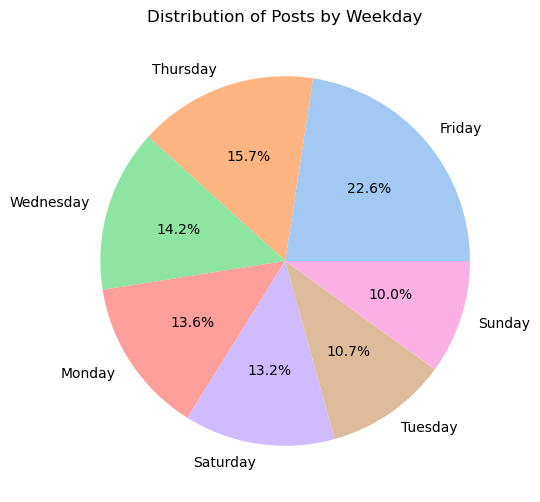

In [127]:
plt.figure(figsize=(6,6))
df['weekday'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)
plt.ylabel('')
plt.title('Distribution of Posts by Weekday')
plt.show()


c:\Users\Ahmed\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


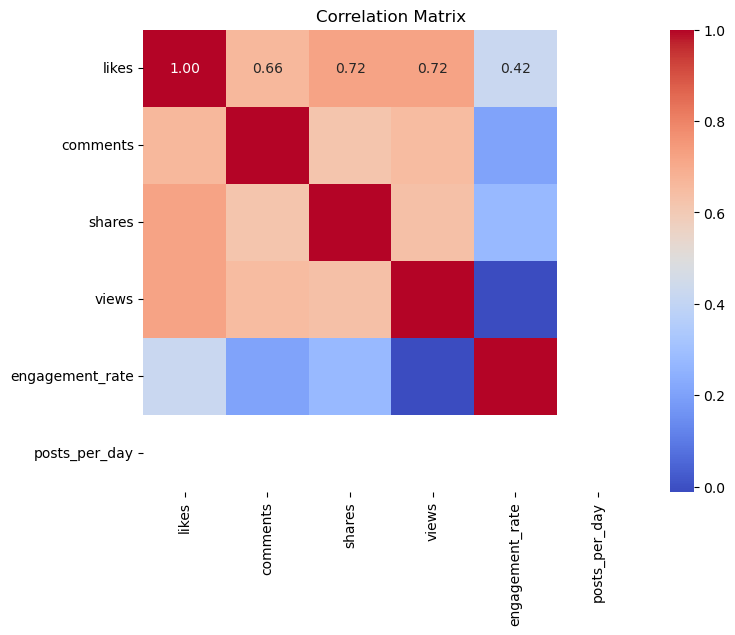

In [128]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
# Shows overall relationships between numeric variables.

In [129]:
df.to_csv('Tiktok Data After EDA.csv', index=False)


print("Tiktok Data After EDA.csv")

Tiktok Data After EDA.csv
